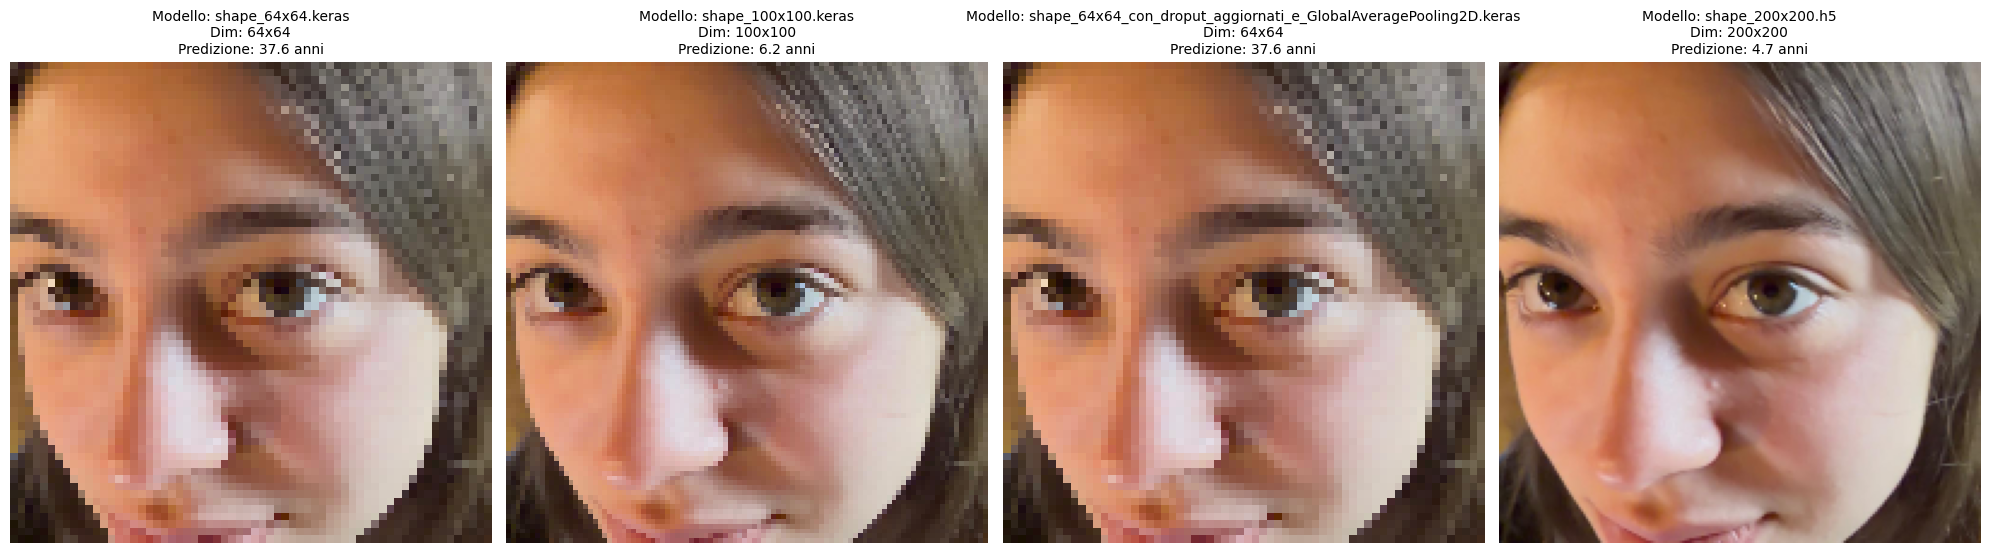

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_and_preprocess_smart(path, target_size):
    img_raw = load_img(path)
    img_array = img_to_array(img_raw)
    
    h, w = img_array.shape[:2]
    min_side = min(h, w)
    img_square = tf.image.resize_with_crop_or_pad(img_array, min_side, min_side)
    
    img_final = tf.image.resize(img_square, target_size)
    return (img_final / 127.5) - 1.0

# configurazione percorsi e file
cartella_input = "input"
nome_foto = "sara2.jpeg"
cartella_modelli = "modelli"
path_img = os.path.join(cartella_input, nome_foto)

# lista dei modelli con le relative risoluzioni attese
modelli_info = [
    {"file": "shape_64x64.keras", "dim": 64},
    {"file": "shape_100x100.keras", "dim": 100},
    {"file": "shape_64x64_con_droput_aggiornati_e_GlobalAveragePooling2D.keras", "dim": 64},
    {"file": "shape_200x200.h5", "dim": 200}
]

if not os.path.exists(path_img):
    print(f"Errore: Immagine {path_img} non trovata.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    for i, info in enumerate(modelli_info):
        nome_file = info["file"]
        dim = info["dim"]
        path_modello = os.path.join(cartella_modelli, nome_file)
        
        if os.path.exists(path_modello):
            try:
                # caricamento modello con gestione errori versione
                model = load_model(path_modello, compile=False)
                model.compile(optimizer='adam', loss='mse', metrics=['mae'])
                
                # pre-elaborazione specifica per la dimensione del modello corrente
                img_ready = load_and_preprocess_smart(path_img, target_size=(dim, dim))
                img_batch = np.expand_dims(img_ready, axis=0)
                
                # predizione
                pred = model.predict(img_batch, verbose=0)
                eta = pred[0][0]
                
                # rendering immagine (denormalizzata)
                img_plot = (img_ready + 1.0) / 2.0
                axes[i].imshow(img_plot)
                axes[i].set_title(f"Modello: {nome_file}\nDim: {dim}x{dim}\nPredizione: {eta:.1f} anni", fontsize=10)
                axes[i].axis('off')
                
            except Exception as e:
                axes[i].text(0.5, 0.5, f"Errore caricamento\n{nome_file}", ha='center', va='center')
                axes[i].axis('off')
                print(f"Errore sul modello {nome_file}: {e}")
        else:
            axes[i].text(0.5, 0.5, f"Modello non trovato\n{nome_file}", ha='center', va='center')
            axes[i].axis('off')
            print(f"File non trovato: {path_modello}")

    plt.tight_layout()
    plt.show()